1. Hücre: Kütüphaneler ve Veriyi Okuma

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# Veriyi oku
df = pd.read_csv('covid.csv')

# Bilinmeyen değerleri (97, 98, 99) NaN ile değiştir ve bu satırları düşür
df.replace([97, 98, 99], np.nan, inplace=True)
df.dropna(inplace=True)

# Veriye hızlıca bir bakış
print("Veri Seti Bilgisi:")
print(df.info())
df.head()

Veri Seti Bilgisi:
<class 'pandas.core.frame.DataFrame'>
Index: 23133 entries, 21 to 566578
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   23133 non-null  object 
 1   sex                  23133 non-null  int64  
 2   patient_type         23133 non-null  int64  
 3   entry_date           23133 non-null  object 
 4   date_symptoms        23133 non-null  object 
 5   date_died            23133 non-null  object 
 6   intubed              23133 non-null  float64
 7   pneumonia            23133 non-null  float64
 8   age                  23133 non-null  float64
 9   pregnancy            23133 non-null  float64
 10  diabetes             23133 non-null  float64
 11  copd                 23133 non-null  float64
 12  asthma               23133 non-null  float64
 13  inmsupr              23133 non-null  float64
 14  hypertension         23133 non-null  float64
 15  other_disease       

,id,sex,patient_type,entry_date,date_symptoms,date_died,intubed,pneumonia,age,pregnancy,...,inmsupr,hypertension,other_disease,cardiovascular,obesity,renal_chronic,tobacco,contact_other_covid,covid_res,icu
21,154fea,1,2,02-06-2020,02-06-2020,9999-99-99,2.0,2.0,25.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1,2.0
30,16e14e,1,2,22-06-2020,17-06-2020,9999-99-99,2.0,2.0,52.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,1.0,1.0,1,2.0
71,149f1c,1,2,17-06-2020,12-06-2020,9999-99-99,2.0,1.0,51.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1,2.0
79,1d5df2,1,2,08-06-2020,07-06-2020,9999-99-99,1.0,1.0,67.0,2.0,...,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1,2.0
93,18f860,1,2,27-05-2020,27-05-2020,9999-99-99,2.0,1.0,59.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1,2.0


2. Hücre: Veri Temizleme (EDA ve Ön İşleme)

In [43]:
import numpy as np

# 1. Hedef sütununu (covid_res) düzenle
# Varsayılan olarak: covid_res = 1 (Pozitif), 2 (Negatif), 3 (Sonuç Bekleniyor)
# Amacımız, 'covid_res == 1' durumunu pozitif (1), diğer durumları negatif (0) olarak etiketlemek.
# Burada covid_res=3 (sonuç bekleniyor) değerlerini de 0 olarak kabul ediyoruz.
df['target'] = df['covid_res'].apply(lambda x: 1 if x == 1 else 0)

# 2. Gereksiz veya hedefle çakışan sütunları atalım
# 'covid_res' sütunu artık 'target' olarak temsil edildiği için onu da atıyoruz.
# Ayrıca 'id' ve tarih sütunları gibi doğrudan modellemede kullanılmayacak sütunları da çıkaralım.
df.drop(['covid_res', 'id', 'entry_date', 'date_symptoms', 'date_died'], axis=1, inplace=True)

# Sütunların düşürülmesinin ardından DataFrame'deki mevcut sütunları kontrol edelim
print("Düşürülen sütunlar sonrası mevcut sütunlar:")
print(df.columns)

# Bilinmeyen değerleri (97, 98, 99) ve eksik değerleri işleme adımları artık veri okuma hücresinde yapıldığı için burada tekrar edilmiyor.

print("Temizlik sonrası veri hazır. Sınıf dağılımı:")
print(df['target'].value_counts())

Düşürülen sütunlar sonrası mevcut sütunlar:
Index(['sex', 'patient_type', 'intubed', 'pneumonia', 'age', 'pregnancy',
       'diabetes', 'copd', 'asthma', 'inmsupr', 'hypertension',
       'other_disease', 'cardiovascular', 'obesity', 'renal_chronic',
       'tobacco', 'contact_other_covid', 'icu', 'target'],
      dtype='object')
Temizlik sonrası veri hazır. Sınıf dağılımı:
target
1    11893
0    11240
Name: count, dtype: int64


3. Hücre: Veriyi Ayırma (Train-Test Split)

In [44]:
# Özellikler (X) ve Hedef (y)
X = df.drop('target', axis=1)
y = df['target']

# %80 Eğitim, %20 Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Eğitim ve Test setleri oluşturuldu.")

Eğitim ve Test setleri oluşturuldu.


4. Hücre: Model Eğitimi (Logistic Regression & Random Forest)

In [45]:
# 1. Model: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# 2. Model: Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print("Modeller başarıyla eğitildi.")

Modeller başarıyla eğitildi.


5. Hücre: Performans Değerlendirme (Confusion Matrix ve Accuracy)

--- LOJİSTİK REGRESYON SONUÇLARI ---
Doğruluk Skoru: 0.6185433326129242

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.62      0.56      0.59      2259
           1       0.62      0.68      0.64      2368

    accuracy                           0.62      4627
   macro avg       0.62      0.62      0.62      4627
weighted avg       0.62      0.62      0.62      4627



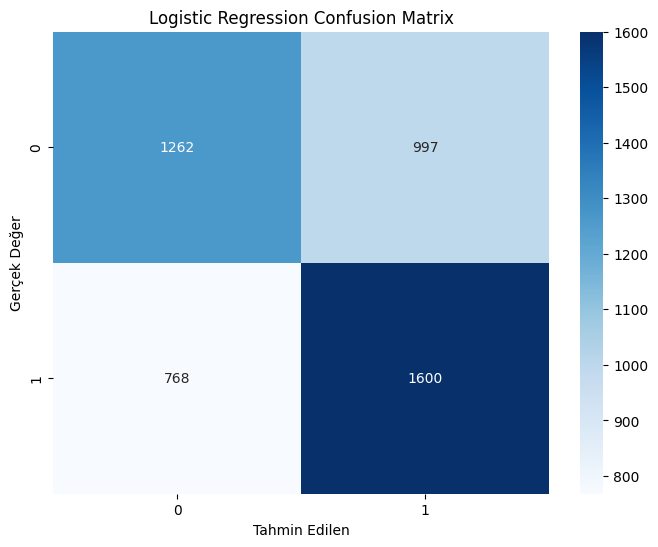



--- RANDOM FOREST SONUÇLARI ---
Doğruluk Skoru: 0.5893667603198617

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.58      0.56      0.57      2259
           1       0.60      0.61      0.60      2368

    accuracy                           0.59      4627
   macro avg       0.59      0.59      0.59      4627
weighted avg       0.59      0.59      0.59      4627



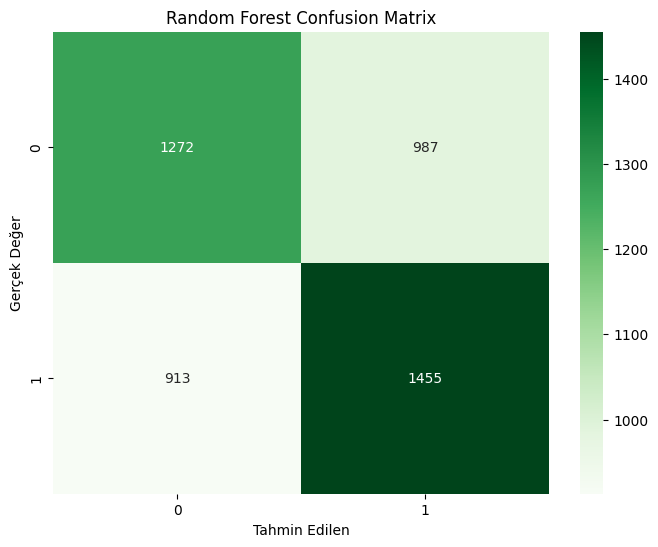

In [46]:
# Tahminleri al
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("--- LOJİSTİK REGRESYON SONUÇLARI ---")
print("Doğruluk Skoru:", accuracy_score(y_test, y_pred_lr))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_lr))

# Karmaşıklık Matrisi Görselleştirme (Lojistik Regresyon)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()

print("\n" + "="*40 + "\n") # Ayırıcı çizgi

print("--- RANDOM FOREST SONUÇLARI ---")
print("Doğruluk Skoru:", accuracy_score(y_test, y_pred_rf))
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_rf))

# Karmaşıklık Matrisi Görselleştirme (Random Forest)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.show()